
# Simple MNIST NN from scratch

In this notebook, I implemented a simple two-layer neural network and trained it on the MNIST digit recognizer dataset. It's meant to be an instructional example, through which you can understand the underlying math of neural networks better.

In [56]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from mpmath import rand

In [57]:
data = pd.read_csv('train.csv')

In [58]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [59]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255

data_train = data[1000:m].T
Y_train = data_train[0]
X_tain = data_train[1:n]
X_tain = X_tain / 255
_, m_train = X_tain.shape

In [60]:
Y_train

array([4, 2, 7, ..., 2, 4, 8], shape=(41000,))

Our NN will have a simple two-layer architecture. Input layer  a[0]
  will have 784 units corresponding to the 784 pixels in each 28x28 input image. A hidden layer  a[1]
  will have 10 units with ReLU activation, and finally our output layer  a[2]
  will have 10 units corresponding to the ten digit classes with softmax activation.

**Forward propagation**

Z[1]=W[1]X+b[1]

A[1]=gReLU(Z[1]))

Z[2]=W[2]A[1]+b[2]

A[2]=gsoftmax(Z[2])

**Backward propagation**

dZ[2]=A[2]−Y

dW[2]=1mdZ[2]A[1]T

dB[2]=1mΣdZ[2]

dZ[1]=W[2]TdZ[2].∗g[1]′(z[1])

dW[1]=1mdZ[1]A[0]T

dB[1]=1mΣdZ[1]

**Parameter updates**

W[2]:=W[2]−αdW[2]

b[2]:=b[2]−αdb[2]

W[1]:=W[1]−αdW[1]

b[1]:=b[1]−αdb[1]

**Vars and shapes**
**Forward prop**

A[0]=X
 : 784 x m
Z[1]∼A[1]
 : 10 x m
W[1]
 : 10 x 784 (as  W[1]A[0]∼Z[1]
 )
B[1]
 : 10 x 1
Z[2]∼A[2]
 : 10 x m
W[1]
 : 10 x 10 (as  W[2]A[1]∼Z[2]
 )
B[2]
 : 10 x 1
**Backprop**

dZ[2]
 : 10 x m (  A[2]
 )
dW[2]
 : 10 x 10
dB[2]
 : 10 x 1
dZ[1]
 : 10 x m (  A[1]
 )
dW[1]
 : 10 x 10
dB[1]
 : 10 x 1

In [61]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2


def ReLU(Z):
    return np.maximum(0, Z)


def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A


def forw_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2


def ReLu_deriv(Z):
    return Z > 0


def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y


def back_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * ReLu_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2


def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [62]:
def get_prediction(A2):
    return np.argmax(A2, 0)


def get_accuracy(prediction, Y):
    print(prediction, Y)
    return np.sum(prediction == Y) / Y.size


def gradient_descendent(X, Y, alpha, iteration):
    W1, b1, W2, b2 = init_params()
    for i in range(iteration):
        Z1, A1, Z2, A2 = forw_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            prediction = get_prediction(A2)
            print(get_accuracy(prediction, Y))
    return W1, b1, W2, b2

In [63]:
W1, b1, W2, b2 = gradient_descendent(X_tain, Y_train, 0.10, 500)

Iteration:  0
[0 7 0 ... 4 8 0] [4 2 7 ... 2 4 8]
0.08509756097560976
Iteration:  10
[0 0 0 ... 8 8 0] [4 2 7 ... 2 4 8]
0.13407317073170733
Iteration:  20
[0 0 0 ... 3 8 0] [4 2 7 ... 2 4 8]
0.2183170731707317
Iteration:  30
[0 0 0 ... 3 8 8] [4 2 7 ... 2 4 8]
0.2946829268292683
Iteration:  40
[4 0 0 ... 3 6 8] [4 2 7 ... 2 4 8]
0.36048780487804877
Iteration:  50
[4 6 7 ... 3 6 8] [4 2 7 ... 2 4 8]
0.4245121951219512
Iteration:  60
[4 6 7 ... 3 6 8] [4 2 7 ... 2 4 8]
0.4786341463414634
Iteration:  70
[4 6 7 ... 3 6 8] [4 2 7 ... 2 4 8]
0.527
Iteration:  80
[4 6 7 ... 3 6 8] [4 2 7 ... 2 4 8]
0.5609268292682927
Iteration:  90
[4 6 7 ... 3 4 8] [4 2 7 ... 2 4 8]
0.5879512195121951
Iteration:  100
[4 6 7 ... 3 4 8] [4 2 7 ... 2 4 8]
0.6105853658536585
Iteration:  110
[4 6 7 ... 3 4 8] [4 2 7 ... 2 4 8]
0.6302439024390244
Iteration:  120
[4 6 7 ... 2 4 8] [4 2 7 ... 2 4 8]
0.6471951219512195
Iteration:  130
[4 6 7 ... 2 4 8] [4 2 7 ... 2 4 8]
0.6636829268292683
Iteration:  140
[4 6 7 ... 

In [64]:
def make_prediction(X, W1, b1, W2, b2):
    _, _, _, A2 = forw_prop(W1, b1, W2, b2, X)
    prediction = get_prediction(A2)
    return prediction


def test_prediction(index, W1, b1, W2, b2):
    current_image = X_tain[:, index, None]
    prediction = make_prediction(X_tain[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Let's look at a couple of examples:

Prediction:  [4]
Label:  4


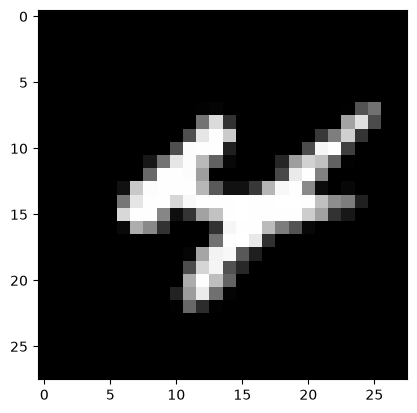

Prediction:  [2]
Label:  2


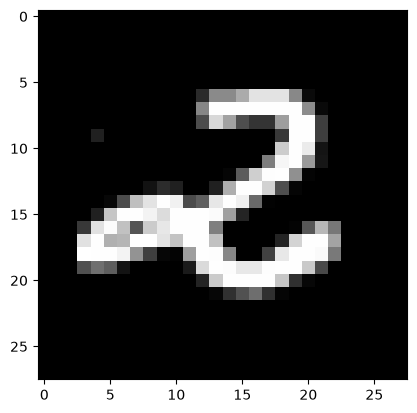

Prediction:  [7]
Label:  7


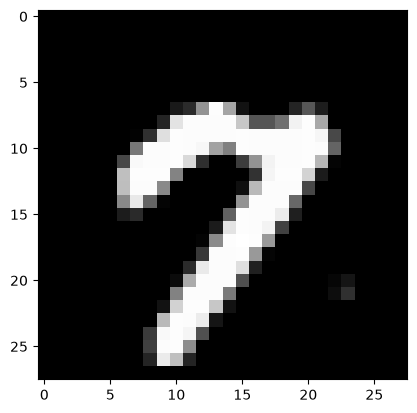

Prediction:  [6]
Label:  6


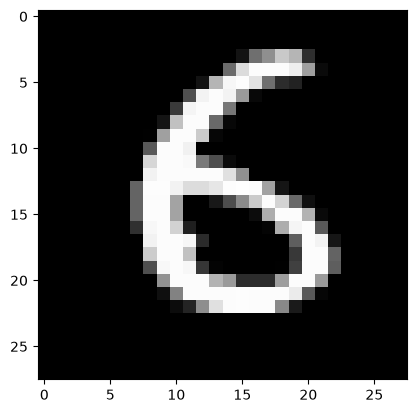

In [65]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

Finally, let's find the accuracy on the dev set:

In [66]:
dev_prediction = make_prediction(X_dev, W1, b1, W2, b2)
get_accuracy(dev_prediction, Y_dev)

[1 9 6 9 6 2 9 4 6 4 5 6 7 6 1 0 2 5 1 5 4 7 0 0 1 8 5 6 6 6 0 8 9 2 8 1 0
 5 9 7 9 9 3 1 7 1 3 7 6 5 7 7 7 7 2 8 3 8 8 2 7 4 4 0 2 1 1 7 1 4 4 4 4 0
 9 8 1 2 0 2 6 3 6 3 7 0 9 9 3 6 8 7 5 6 9 7 1 2 9 2 4 6 0 9 7 9 0 7 2 4 5
 3 4 6 9 3 5 0 3 0 5 6 1 5 8 1 4 2 2 7 5 7 0 0 9 5 8 3 6 2 8 9 0 6 1 3 3 9
 9 6 4 7 6 6 7 3 5 1 8 6 7 9 1 5 2 4 8 6 9 1 9 5 0 3 0 4 1 4 8 8 4 2 0 0 3
 8 6 3 2 7 6 8 0 7 3 3 7 3 1 7 9 4 1 7 2 4 1 7 6 5 0 1 4 8 7 3 8 0 4 8 3 1
 5 7 0 4 9 6 4 1 9 2 2 4 1 1 6 4 7 7 1 9 6 9 3 5 7 0 0 1 8 0 7 1 7 4 2 7 4
 9 2 9 5 0 3 0 6 5 7 0 4 5 6 1 5 1 3 8 9 0 8 0 7 3 8 1 3 5 2 6 5 5 7 9 0 5
 6 1 4 0 9 6 0 3 8 7 7 0 3 9 0 3 7 6 4 3 3 1 0 8 9 4 3 8 2 1 8 3 3 8 5 7 7
 6 9 1 7 4 9 3 9 3 4 1 0 4 9 6 6 6 5 4 0 5 0 1 0 9 0 0 7 7 9 1 9 6 3 2 8 8
 5 3 6 1 6 6 7 9 9 2 3 7 5 1 3 2 9 0 1 7 7 6 3 8 1 2 1 4 1 7 2 6 4 3 4 6 9
 8 1 5 2 9 4 3 1 1 4 4 0 1 5 1 4 8 7 6 0 3 0 3 5 3 2 5 2 5 4 4 9 8 4 9 0 9
 5 7 7 4 1 4 5 9 5 2 6 8 0 6 8 8 2 0 2 3 1 2 1 2 7 7 7 8 2 4 9 3 6 5 4 7 1
 2 9 9 8 1 2 2 1 8 1 2 2 

np.float64(0.848)